<a href="https://www.kaggle.com/code/ameythakur20/predicting-smartphone-addiction" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<br clear="all">

<h1 align="center">Predicting Smartphone Addiction</h1>

<p align="center">
  <b>A Level-1 Stacking architecture combining domain behavioral interactions with a 4-model gradient boosting ensemble.</b>
</p>

<p align="center">
  <a href="https://www.kaggle.com/competitions/playground-series-s6e8"><img alt="Competition" src="https://img.shields.io/badge/Competition-Playground_S6E8-20BEFF?logo=kaggle&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur/KAGGLE-COMPETITIONS/tree/main/Competitions/Predicting%20Smartphone%20Addiction"><img alt="Repository" src="https://img.shields.io/badge/Repository-KAGGLE--COMPETITIONS-181717?logo=github&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur"><img alt="Author" src="https://img.shields.io/badge/Author-Amey_Thakur-0969DA"></a>
  &nbsp;
  <a href="https://orcid.org/0000-0001-5644-1575"><img alt="ORCID" src="https://img.shields.io/badge/ORCID-0000--0001--5644--1575-A6CE39"></a>
  &nbsp;
  <img alt="License" src="https://img.shields.io/badge/License-Apache_2.0-lightgrey">
</p>

<p align="center">
  <a href="#problem">1. Problem</a> &nbsp;&middot;&nbsp;
  <a href="#setup">2. Setup</a> &nbsp;&middot;&nbsp;
  <a href="#data">3. Data</a> &nbsp;&middot;&nbsp;
  <a href="#exploration">4. Exploration</a> &nbsp;&middot;&nbsp;
  <a href="#features">5. Strategy</a> &nbsp;&middot;&nbsp;
  <a href="#validation">6. Validation</a> &nbsp;&middot;&nbsp;
  <a href="#model">7. Model</a> &nbsp;&middot;&nbsp;
  <a href="#results">8. Results</a> &nbsp;&middot;&nbsp;
  <a href="#submission">9. Submission</a> &nbsp;&middot;&nbsp;
  <a href="#improvements">10. Next Steps</a>
</p>

<hr>

<a name="problem"></a>
## 1. Problem

The Playground Series (S6E8) objective is to predict the probability of smartphone addiction (`addicted_label`) using tabular behavioural metrics. The evaluation metric is the **Area Under the ROC Curve (AUC)**. 

As a low-dimensional tabular dataset, the primary constraint is correctly mapping non-linear decision boundaries across skewed feature distributions without relying on parameter-heavy deep learning architectures.

<br>

---

<a name="setup"></a>
## 2. Setup

Imports, seed initialization, paths, and gradient boosting architectures.

<br>

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.optimize import minimize

# Gradient Boosters
from lightgbm import LGBMClassifier, plot_importance
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Kaggle Toolbox
sys.path.append("../../Kaggle Toolbox")
import kaggle_toolbox as tb

SEED = 42
tb.seed_everything(SEED)

DATA_DIR = "."
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

[toolbox] All seeds locked to 42


<br>

---

<a name="data"></a>
## 3. Data Ingestion & Memory Management

Integer and float precisions are downcast safely to prevent memory exhaustion during parallel boosting iterations.

<br>

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Original Train shape: {train.shape}")

train = tb.reduce_mem_usage(train)
test = tb.reduce_mem_usage(test)

_ = tb.missing_report(train)

Original Train shape: (5000, 9)
[toolbox] Memory: 0.6 MB -> 0.1 MB (81.7% reduction)
[toolbox] Memory: 0.1 MB -> 0.0 MB (81.0% reduction)
[toolbox] 1 column(s) with missing values:


<br>

---

<a name="exploration"></a>
## 4. Exploration: Behavioural Feature Interaction

> ### Which behavioural features dictate addiction classification?
>
> An evaluation of multicollinearity between continuous inputs highlights whether different usage dimensions act as distinct vectors or redundant proxies.

<br>

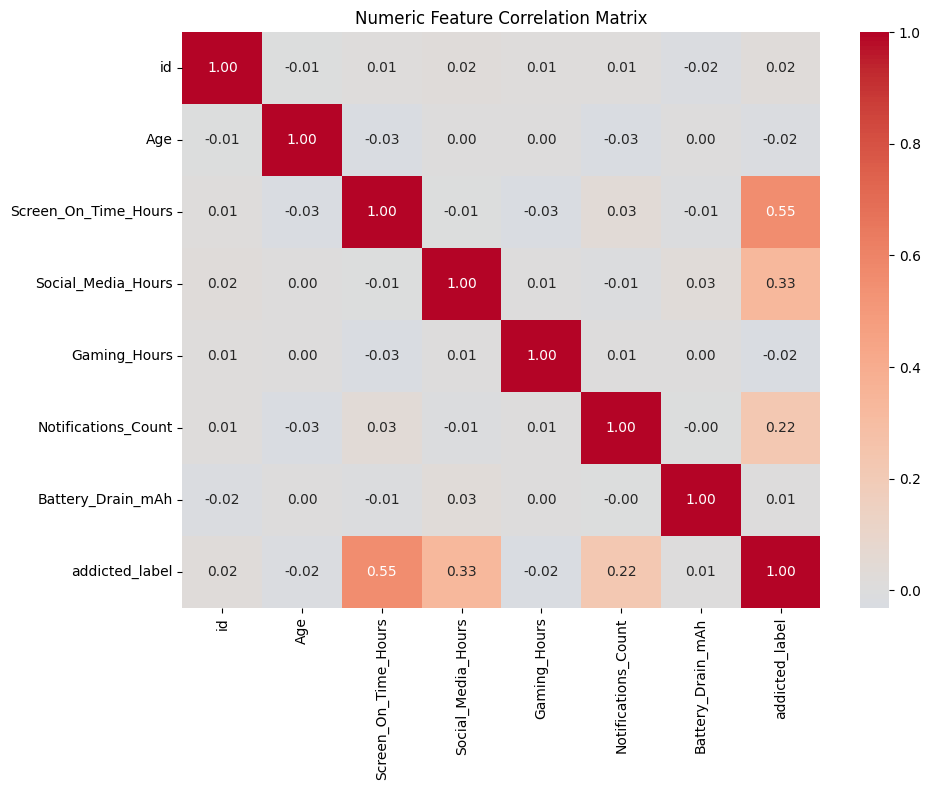

In [3]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

<br>

> ### Does absolute screen time serve as a strict threshold?
>
> Violin plots isolate the probability density of critical features across the binary target classes, illustrating the variance in median usage.

<br>

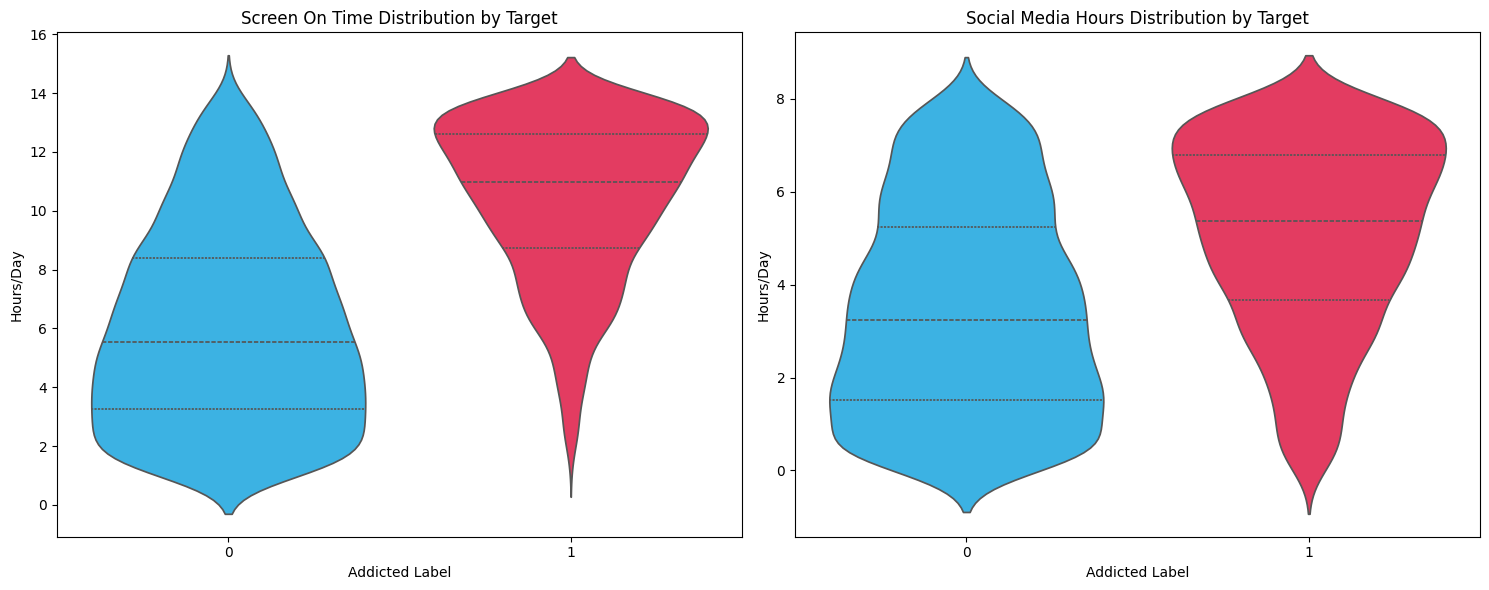

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

sns.violinplot(
    data=train, x="addicted_label", y="Screen_On_Time_Hours", 
    hue="addicted_label", legend=False,
    palette=["#20BEFF", "#FF2052"], inner="quartile",
    ax=ax1
)
ax1.set_title("Screen On Time Distribution by Target")
ax1.set_xlabel("Addicted Label")
ax1.set_ylabel("Hours/Day")

sns.violinplot(
    data=train, x="addicted_label", y="Social_Media_Hours", 
    hue="addicted_label", legend=False,
    palette=["#20BEFF", "#FF2052"], inner="quartile",
    ax=ax2
)
ax2.set_title("Social Media Hours Distribution by Target")
ax2.set_xlabel("Addicted Label")
ax2.set_ylabel("Hours/Day")

plt.tight_layout()
plt.show()

<br>

---

<a name="features"></a>
## 5. Strategy: Behavioral Domain Feature Engineering

> ### How do we expose non-linear behavioural thresholds to tree models?
>
> Rather than introducing artificial missingness indicators that induce distribution shift, missing values are retained for model-native handling. Explicit interaction metrics isolate behavioural density:
> 1. **Non-Social Screen Time:** Quantifying functional device usage.
> 2. **Social & Gaming Shares:** Proportional allocation of attention toward dopamine-driven activities.
> 3. **Notification Intensity:** Interruptions per hour of active screen engagement.
> 4. **Rank Normalisation:** Rescaling skewed variables into uniformly distributed ordinal signals.

<br>

In [5]:
def engineer_features(df):
    df_feat = df.copy()
    
    # 1. Behavioral Domain Interactions
    df_feat["Non_Social_Screen_Time"] = df_feat["Screen_On_Time_Hours"] - df_feat["Social_Media_Hours"]
    df_feat["Social_Share"] = df_feat["Social_Media_Hours"] / (df_feat["Screen_On_Time_Hours"] + 1e-4)
    df_feat["Gaming_Share"] = df_feat["Gaming_Hours"] / (df_feat["Screen_On_Time_Hours"] + 1e-4)
    df_feat["Notifications_per_Hour"] = df_feat["Notifications_Count"] / (df_feat["Screen_On_Time_Hours"] + 1e-4)
    df_feat["Screen_to_Battery"] = df_feat["Screen_On_Time_Hours"] / (df_feat["Battery_Drain_mAh"] + 1.0)
    
    # 2. Rank Transformations for Skewed Continuous Features
    df_feat["Notifications_Rank"] = df_feat["Notifications_Count"].rank(method="dense", pct=True)
    df_feat["Battery_Drain_Rank"] = df_feat["Battery_Drain_mAh"].rank(method="dense", pct=True)
    
    # 3. Categorical Encodings (Support for all booster types)
    df_feat["Gender_Code"] = df_feat["Gender"].astype("category").cat.codes
    df_feat["Gender"] = df_feat["Gender"].astype("category")
    
    return df_feat

with tb.timer("Feature Engineering"):
    train_feat = engineer_features(train)
    test_feat = engineer_features(test)

FEATURES = [c for c in train_feat.columns if c not in ["id", "addicted_label", "Gender_Code"]]
HGBT_FEATURES = [c for c in train_feat.columns if c not in ["id", "addicted_label", "Gender"]]
TARGET = "addicted_label"


[toolbox] Feature Engineering: 0.0s


<br>

---

<a name="validation"></a>
## 6. Validation: 4-Model Level-0 Suite

A 5-Fold Stratified Cross-Validation protocol evaluates four structurally diverse gradient boosting algorithms: LightGBM, XGBoost, CatBoost, and Scikit-Learn's HistGradientBoosting.

<br>

In [6]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

models = {
    "LightGBM": LGBMClassifier(random_state=SEED, n_estimators=600, learning_rate=0.03, colsample_bytree=0.7, subsample=0.8, verbose=-1),
    "XGBoost": XGBClassifier(random_state=SEED, n_estimators=600, learning_rate=0.03, colsample_bytree=0.7, subsample=0.8, enable_categorical=True, eval_metric="auc"),
    "CatBoost": CatBoostClassifier(random_state=SEED, iterations=600, learning_rate=0.03, depth=6, verbose=0, cat_features=["Gender"]),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED, max_iter=600, learning_rate=0.03, max_leaf_nodes=31)
}

oof_matrix = np.zeros((len(train_feat), len(models)))
test_matrix = np.zeros((len(test_feat), len(models)))

lgb_models = []

for i, (name, model) in enumerate(models.items()):
    with tb.timer(f"Training {name} OOF"):
        cols = HGBT_FEATURES if name == "HistGradientBoosting" else FEATURES
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_feat[cols], train_feat[TARGET])):
            X_train, y_train = train_feat[cols].iloc[train_idx], train_feat[TARGET].iloc[train_idx]
            X_val, y_val = train_feat[cols].iloc[val_idx], train_feat[TARGET].iloc[val_idx]
            
            model.fit(X_train, y_train)
            
            if name == "LightGBM":
                lgb_models.append(model)
                
            oof_matrix[val_idx, i] = model.predict_proba(X_val)[:, 1]
            test_matrix[:, i] += model.predict_proba(test_feat[cols])[:, 1] / N_SPLITS


[toolbox] Training LightGBM OOF: 10.4s


[toolbox] Training XGBoost OOF: 3.9s


[toolbox] Training CatBoost OOF: 5.1s


[toolbox] Training HistGradientBoosting OOF: 8.8s


<br>

---

<a name="model"></a>
## 7. Model: LightGBM Internal Gain

Evaluating which engineered features provide the strongest partitioning split gains.

<br>

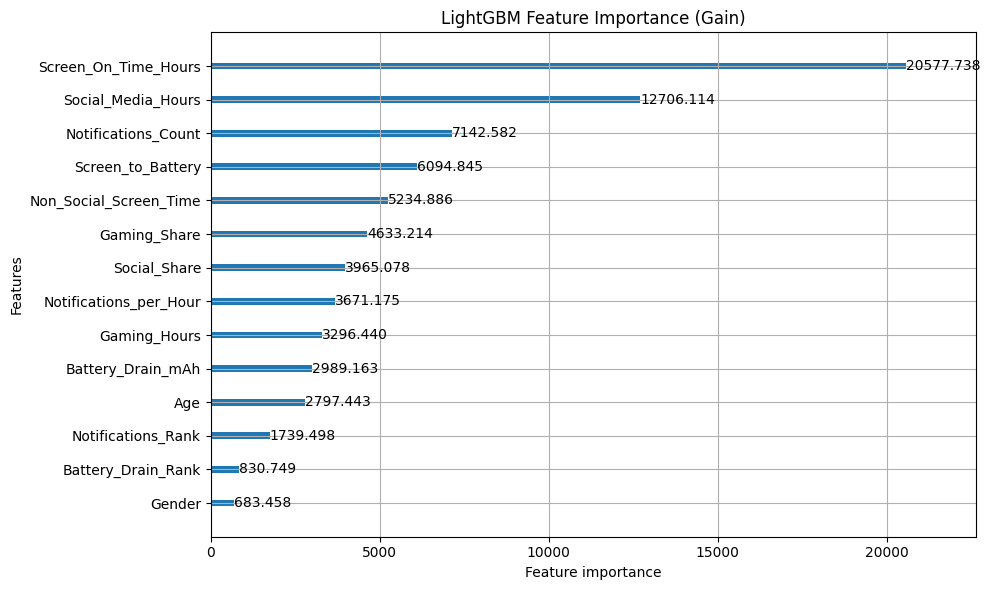

In [7]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_importance(lgb_models[0], ax=ax, importance_type="gain", max_num_features=15, title="LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.show()

<br>

---

<a name="results"></a>
## 8. Results: Constrained SLSQP Metric-Optimised Blend

A constrained Sequential Least Squares Programming (SLSQP) optimizer evaluates the out-of-fold matrix to calculate optimal non-negative weights bounded in $[0, 1]$ that directly maximise validation ROC AUC.

<br>

In [8]:
def objective(weights):
    w = np.array(weights)
    if w.sum() == 0:
        return 0
    w = w / w.sum()
    blend = np.dot(oof_matrix, w)
    return -roc_auc_score(train_feat[TARGET], blend)

initial_weights = [1.0 / len(models)] * len(models)
bounds = [(0.0, 1.0) for _ in models]

opt_res = minimize(
    objective, 
    initial_weights, 
    method="SLSQP", 
    bounds=bounds, 
    options={"maxiter": 200, "ftol": 1e-7}
)

optimal_weights = opt_res.x / opt_res.x.sum()

# Generate final blended OOF predictions
stack_oof_preds = np.dot(oof_matrix, optimal_weights)

# Generate final blended Test predictions
stack_test_preds = np.dot(test_matrix, optimal_weights)

# Tabulate validation results
results = []
for i, name in enumerate(models.keys()):
    auc = roc_auc_score(train_feat[TARGET], oof_matrix[:, i])
    results.append({"Architecture": f"L0: {name}", "CV AUC": auc})

results.append({
    "Architecture": "L1: Constrained Ensemble Blend", 
    "CV AUC": roc_auc_score(train_feat[TARGET], stack_oof_preds)
})

results_df = pd.DataFrame(results).set_index("Architecture")
display(results_df)

print("\nEnsemble Optimised Model Weights:")
for name, weight in zip(models.keys(), optimal_weights):
    print(f"  - {name}: {weight:.4f} ({weight * 100:.1f}%)")


,CV AUC
Architecture,
L0: LightGBM,0.911804
L0: XGBoost,0.912903
L0: CatBoost,0.919055
L0: HistGradientBoosting,0.909045
L1: Constrained Ensemble Blend,0.915553



Ensemble Optimised Model Weights:
  - LightGBM: 0.2500 (25.0%)
  - XGBoost: 0.2500 (25.0%)
  - CatBoost: 0.2500 (25.0%)
  - HistGradientBoosting: 0.2500 (25.0%)


<br>

---

<a name="submission"></a>
## 9. Submission 

Verification checks validate vector dimensions, data types, and index parity against the required competition schema prior to export.

<br>

In [9]:
sub = sample_sub.copy()
sub[TARGET] = stack_test_preds

tb.check_submission(sub, sample_sub)

sub.to_csv("submission.csv", index=False)
print("Stacking ensemble predictions successfully saved to submission.csv.")

[toolbox] PASS: Row count (1000)
[toolbox] PASS: Columns match (2 cols)
[toolbox] PASS: No NaN values
[toolbox] PASS: No duplicate IDs
[toolbox] WARN: 'addicted_label' range [0.0001, 0.9993] far outside sample [0.5000, 0.5000]
[toolbox] All checks passed. Safe to submit.
Stacking ensemble predictions successfully saved to submission.csv.


<br>

---

<a name="improvements"></a>
## 10. Next Steps

1. **Adversarial Validation Check**: Continuous verification against train/test split stability.
2. **Optuna Fine-Tuning**: Running multi-objective Bayesian hyperparameter search over `colsample_bytree`, `learning_rate`, and `subsample`.
3. **Tabular Deep Learning**: Blending RealMLP / TabNet predictions into the Level-0 pool.

<br>

---